# Simple CatBoost — MS Subtype Classification

**Goal:** Classify MS subtypes using CatBoost gradient boosting.

**About CatBoost:** Like XGBoost but with two special tricks: ordered boosting (reduces overfitting) and native categorical feature support. It also handles missing values internally!

---

In [1]:
# Import all the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
from catboost import CatBoostClassifier, Pool
# Set seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {'RRMS': '#2196F3', 'SPMS': '#FF5722', 'PPMS': '#4CAF50', 'CIS': '#9C27B0'}
ORDER = ['RRMS', 'SPMS', 'PPMS', 'CIS']

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Loading the Dataset

We load the CSV file and take a quick look at its shape and first few rows.

In [2]:
df = pd.read_csv('../datasets/ms_dataset.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 565, Columns: 17


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,44.0,0,38.0,6.0,6.0,0.0,0.0,1028167.8,621739.1,474379.0,36.0,6807.9,0.261700,0.604700,0.461400,0.006621,PPMS
1,50.0,1,47.0,5.7,3.0,0.0,0.0,1309256.4,442370.6,466771.9,34.0,21719.1,0.463300,0.337900,0.356500,0.016589,PPMS
2,31.0,0,29.0,2.5,2.0,0.0,0.0,1493401.0,742487.0,513052.0,6.0,200.0,1.250000,0.497179,0.343546,0.000134,RRMS
3,50.0,0,42.0,5.7,8.0,0.0,1.0,1347866.4,604577.7,460298.3,3.0,19638.3,0.569400,0.448500,0.341500,0.014570,PPMS
4,39.6,0,37.0,2.0,2.6,1.0,0.0,1730165.0,732144.0,396716.0,8.0,404.0,0.769231,0.423164,0.229294,0.000234,CIS


## 3. Exploring the Data

Before building a model, we need to understand our data — check for missing values, see how many patients are in each subtype, and look at feature distributions.

### 3.1 Basic Info

In [3]:
print("Data types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe().round(2)

Data types:
age                      float64
sex_encoded                int64
age_at_onset             float64
edss                     float64
disease_duration         float64
relapse_count            float64
treatment_status         float64
brain_volume             float64
gm_volume                float64
wm_volume                float64
lesion_count             float64
lesion_volume            float64
edss_progression_rate    float64
gm_ratio                 float64
wm_ratio                 float64
lesion_burden_ratio      float64
subtype                      str
dtype: object

Basic statistics:


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio
count,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,539.00,565.00,565.00,565.00
mean,41.30,0.38,33.67,3.26,7.63,0.57,0.63,1364957.22,640627.73,440260.49,31.32,9692.20,0.82,0.47,0.32,0.01
std,12.47,0.49,10.01,2.12,6.56,0.62,0.48,157237.55,101924.25,59792.20,42.43,10037.31,1.52,0.08,0.05,0.01
min,15.00,0.00,7.50,0.00,0.00,0.00,0.00,922515.10,368110.90,268459.00,0.00,0.00,0.00,0.29,0.19,0.00
25%,31.00,0.00,26.70,1.50,2.90,0.00,0.00,1265129.00,578046.00,399868.00,10.00,2014.00,0.24,0.43,0.29,0.00
50%,40.60,0.00,33.20,3.00,5.80,0.00,1.00,1377883.00,652455.00,444134.00,22.00,6539.00,0.45,0.47,0.33,0.00
75%,51.00,1.00,40.00,5.00,11.40,1.00,1.00,1473326.00,716741.00,476837.00,40.00,14194.00,0.80,0.52,0.35,0.01
max,71.00,1.00,65.00,8.50,35.00,2.00,1.00,1730165.00,884733.00,628779.00,497.00,60999.00,20.00,0.86,0.49,0.05


In [4]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
edss_progression_rate    26
dtype: int64

Duplicate rows: 0


### 3.2 How Many Patients in Each Subtype?

subtype
RRMS    275
SPMS    125
PPMS    125
CIS      40
Name: count, dtype: int64


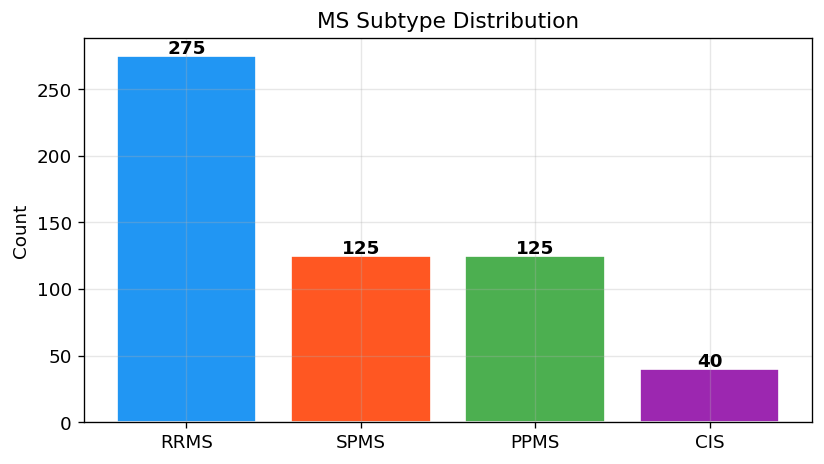

In [5]:
counts = df['subtype'].value_counts().reindex(ORDER)
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ORDER, counts, color=[COLORS[s] for s in ORDER], edgecolor='white')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('MS Subtype Distribution')
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions by Subtype

Boxplots help us see which features differ across subtypes — features with clear separation will be helpful for classification.

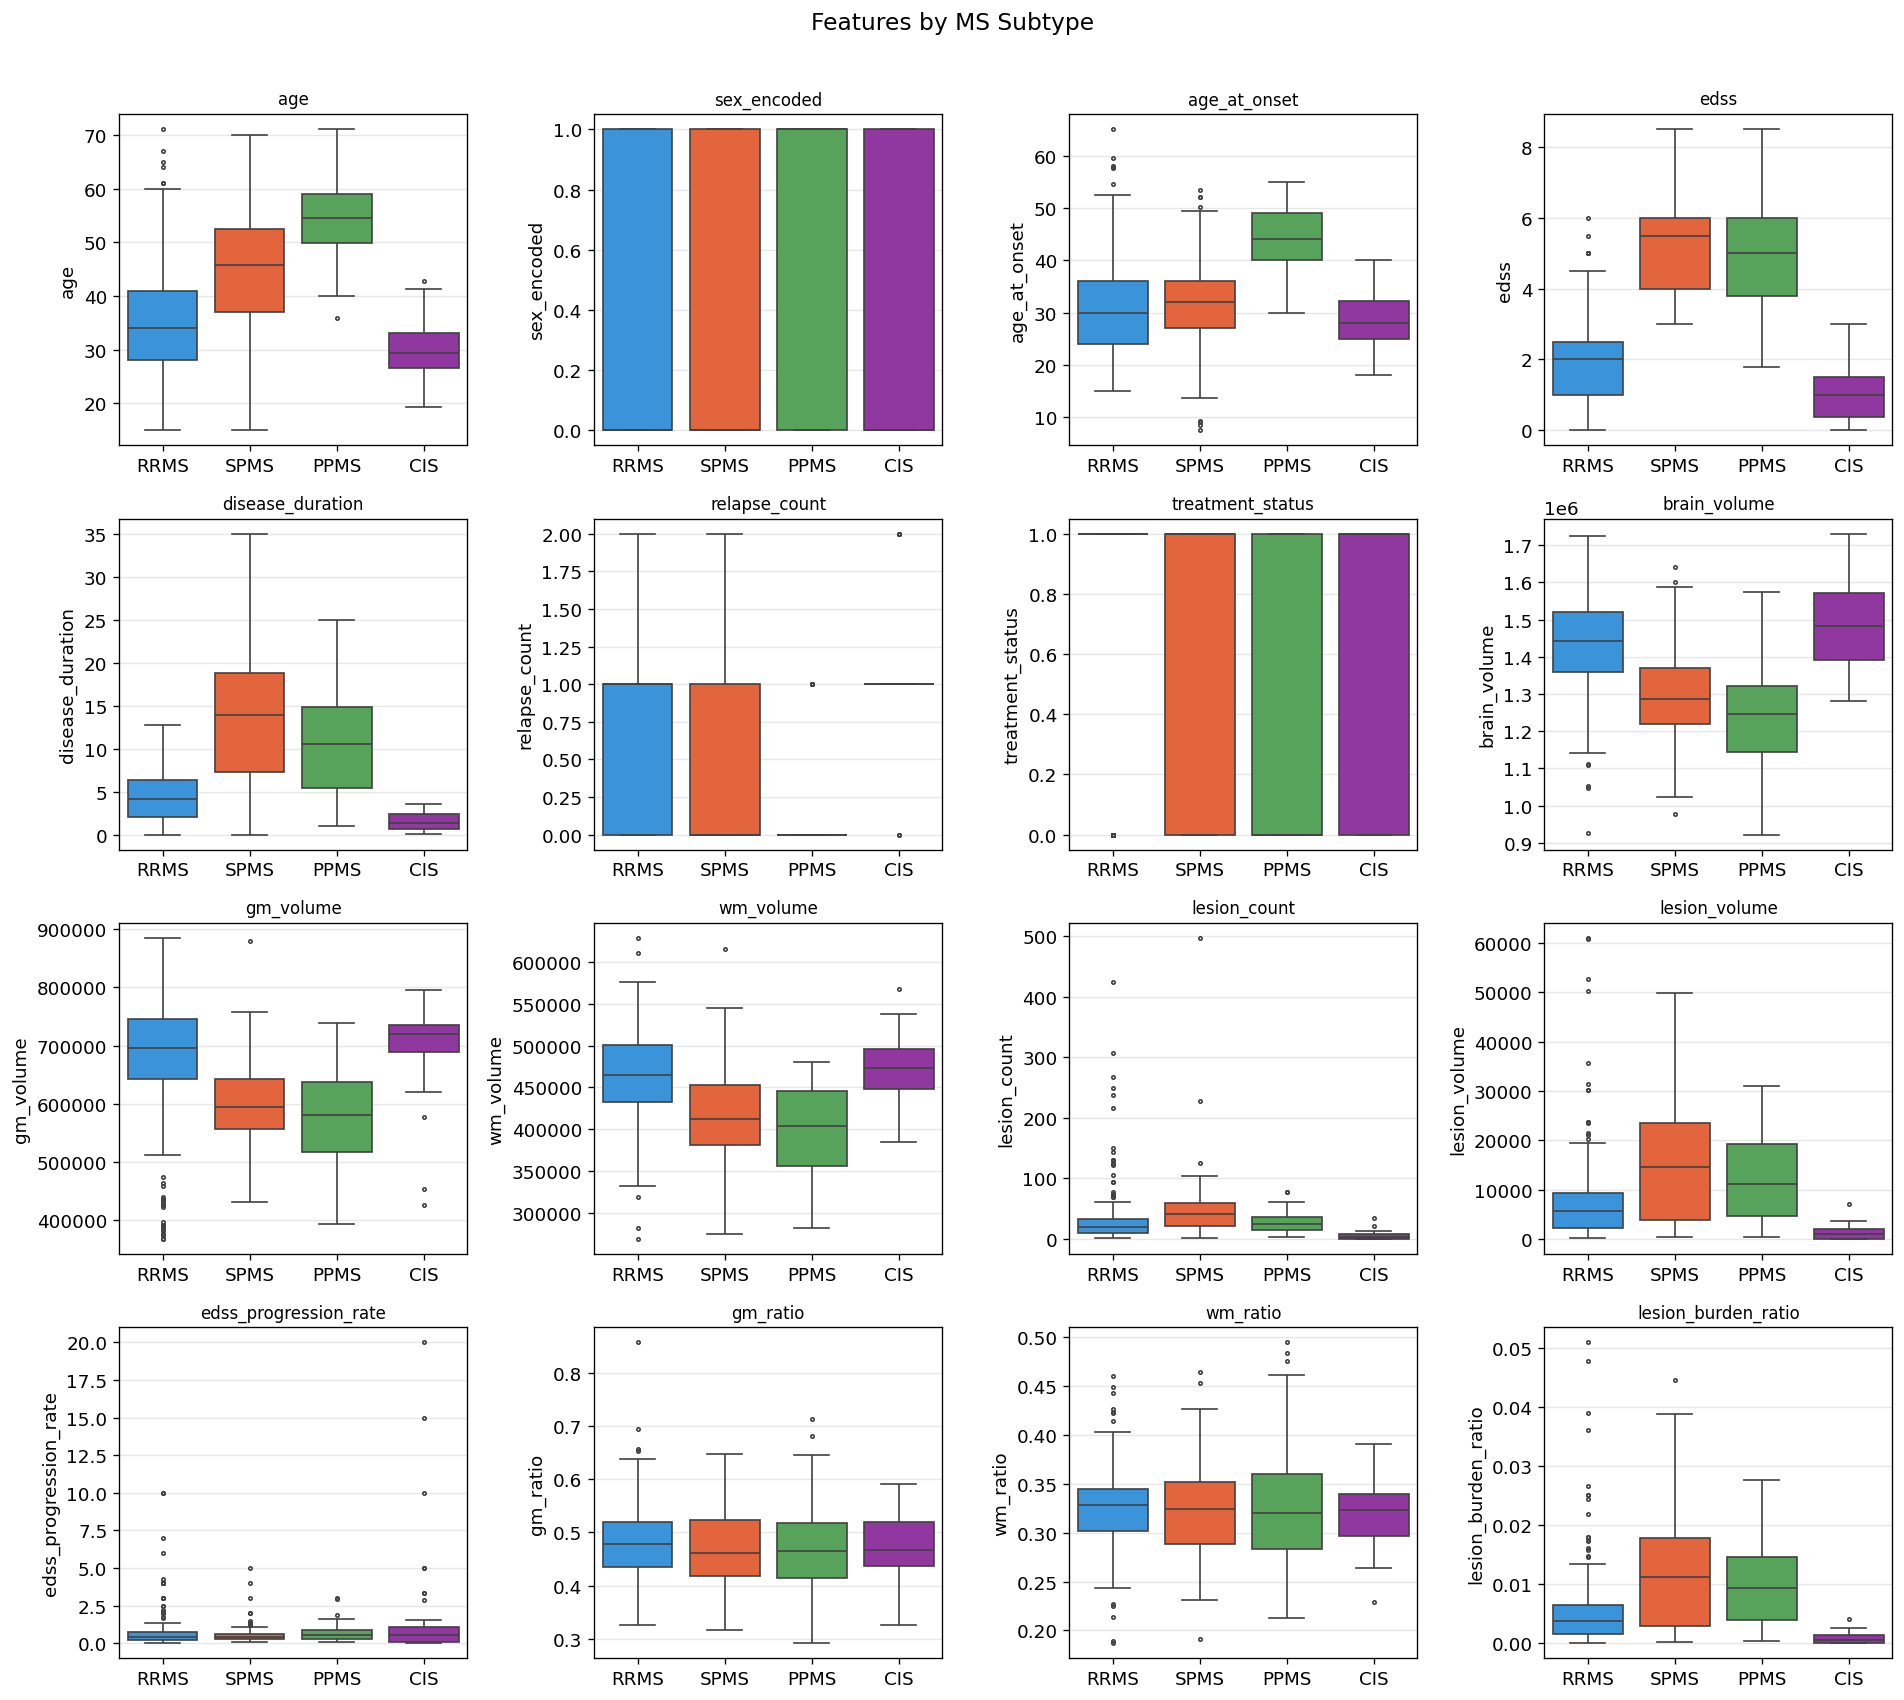

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ncols = 4
nrows = (len(numeric_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='subtype', y=col, order=ORDER, palette=COLORS, ax=axes[i], fliersize=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Features by MS Subtype', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

Shows how features relate to each other. Highly correlated features carry similar information.

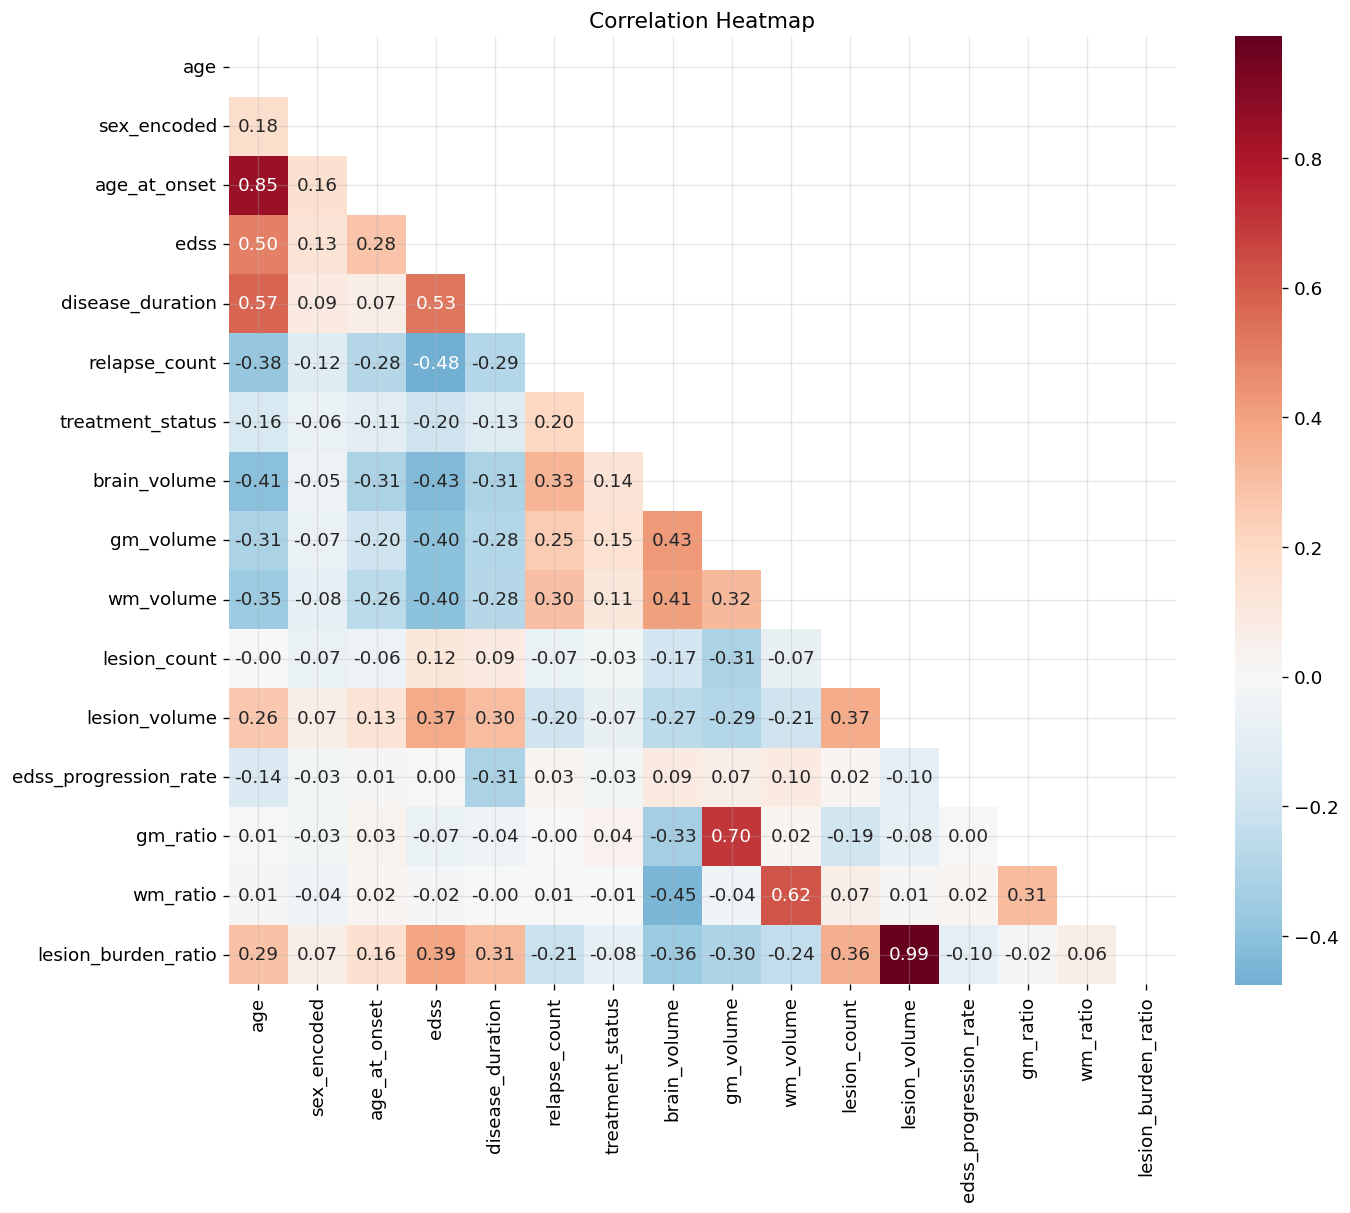

In [7]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

CatBoost is special — it handles missing values and categorical features internally. No scaling or imputation needed!

In [8]:
feature_cols = [col for col in df.columns if col != 'subtype']
X = df[feature_cols]
y = df['subtype']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Mark categorical features
cat_features = ['sex_encoded', 'treatment_status']
cat_indices = [feature_cols.index(c) for c in cat_features if c in feature_cols]
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype(int)
print(f"Classes: {list(class_names)}")
print(f"Categorical features: {cat_features}")

Classes: ['CIS', 'PPMS', 'RRMS', 'SPMS']
Categorical features: ['sex_encoded', 'treatment_status']


In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
train_pool = Pool(X_train, y_train, cat_features=cat_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_indices)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 452, Test: 113


## 5. Building the Model

In [10]:
model = CatBoostClassifier(
    loss_function='MultiClass', iterations=500,
    learning_rate=0.1, depth=6, l2_leaf_reg=3.0,
    auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=0
)
print("Model created")

Model created


## 6. Cross-Validation

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc, cv_f1m, cv_f1w = [], [], []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    fold_pool = Pool(X_train.iloc[tr_idx], y_train[tr_idx], cat_features=cat_indices)
    fm = CatBoostClassifier(loss_function='MultiClass', iterations=500, learning_rate=0.1,
                            depth=6, l2_leaf_reg=3.0, auto_class_weights='Balanced',
                            random_seed=RANDOM_STATE, verbose=0)
    fm.fit(fold_pool)
    yp = fm.predict(X_train.iloc[val_idx]).flatten().astype(int)
    cv_acc.append(accuracy_score(y_train[val_idx], yp))
    cv_f1m.append(f1_score(y_train[val_idx], yp, average='macro'))
    cv_f1w.append(f1_score(y_train[val_idx], yp, average='weighted'))
    print(f"  Fold {fold}: Acc={cv_acc[-1]:.4f}, F1={cv_f1m[-1]:.4f}")

cv_results = {'test_accuracy': np.array(cv_acc), 'test_f1_macro': np.array(cv_f1m), 'test_f1_weighted': np.array(cv_f1w)}
print(f"\nAverage: Acc={np.mean(cv_acc):.4f}, Macro F1={np.mean(cv_f1m):.4f}")

  Fold 1: Acc=0.8791, F1=0.8509


  Fold 2: Acc=0.8791, F1=0.8550


  Fold 3: Acc=0.8889, F1=0.8414


  Fold 4: Acc=0.8889, F1=0.8535


  Fold 5: Acc=0.8667, F1=0.7854

Average: Acc=0.8805, Macro F1=0.8372


## 7. Train on Full Training Set

In [12]:
model.fit(train_pool)
print(f"Trained with {model.tree_count_} trees")

Trained with 500 trees


## 8. Test Set Evaluation

In [13]:
y_pred = model.predict(test_pool).flatten().astype(int)
y_proba = model.predict_proba(test_pool)

print("Test Results:")
print(f"  Accuracy:     {accuracy_score(y_test, y_pred):.4f}")
print(f"  Macro F1:     {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Weighted F1:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Results:
  Accuracy:     0.8850
  Macro F1:     0.8527
  Weighted F1:  0.8860

              precision    recall  f1-score   support

         CIS     0.7000    0.8750    0.7778         8
        PPMS     0.8148    0.8800    0.8462        25
        RRMS     0.9444    0.9273    0.9358        55
        SPMS     0.9091    0.8000    0.8511        25

    accuracy                         0.8850       113
   macro avg     0.8421    0.8706    0.8527       113
weighted avg     0.8906    0.8850    0.8860       113



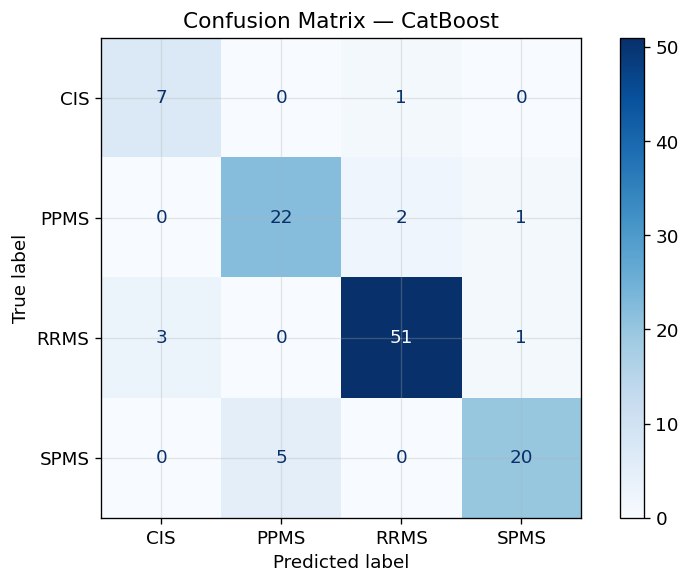

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — CatBoost')
plt.tight_layout()
plt.show()

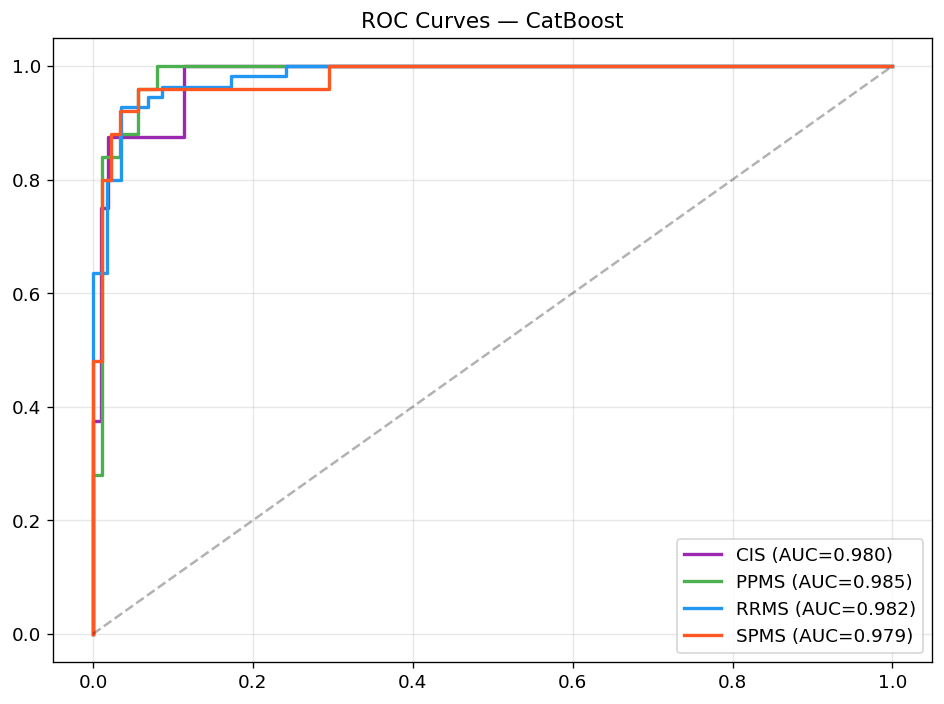

Overall ROC-AUC: 0.9815


In [15]:
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})', color=COLORS.get(name))
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_title('ROC Curves — CatBoost')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f"Overall ROC-AUC: {roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'):.4f}")

## 9. Feature Importance

Which features does the model rely on most?

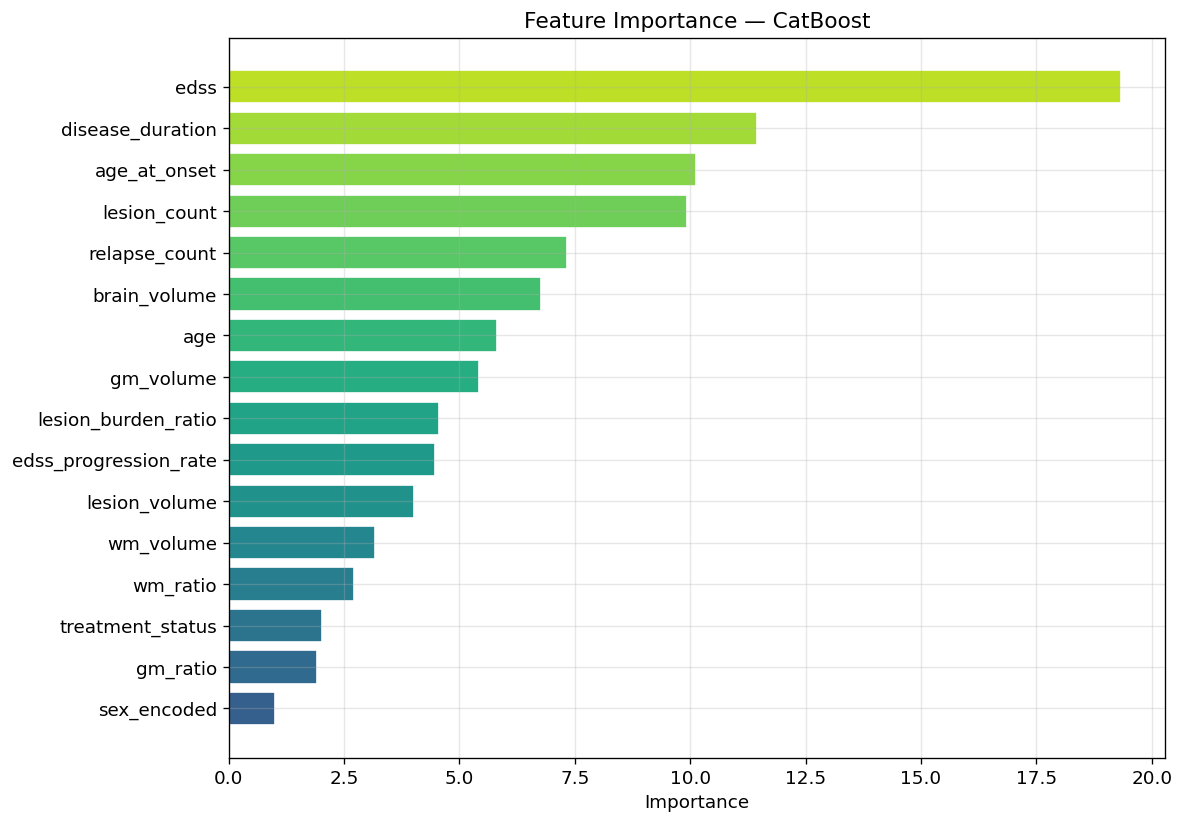

Top 5 features:
  edss                           19.3261
  disease_duration               11.4381
  age_at_onset                   10.1208
  lesion_count                   9.9288
  relapse_count                  7.3401


In [16]:
imp = model.get_feature_importance()
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': imp}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=plt.cm.viridis(np.linspace(0.3, 0.9, len(imp_df))), edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — CatBoost')
plt.tight_layout()
plt.show()

print("Top 5 features:")
for _, row in imp_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

## 10. Summary Dashboard

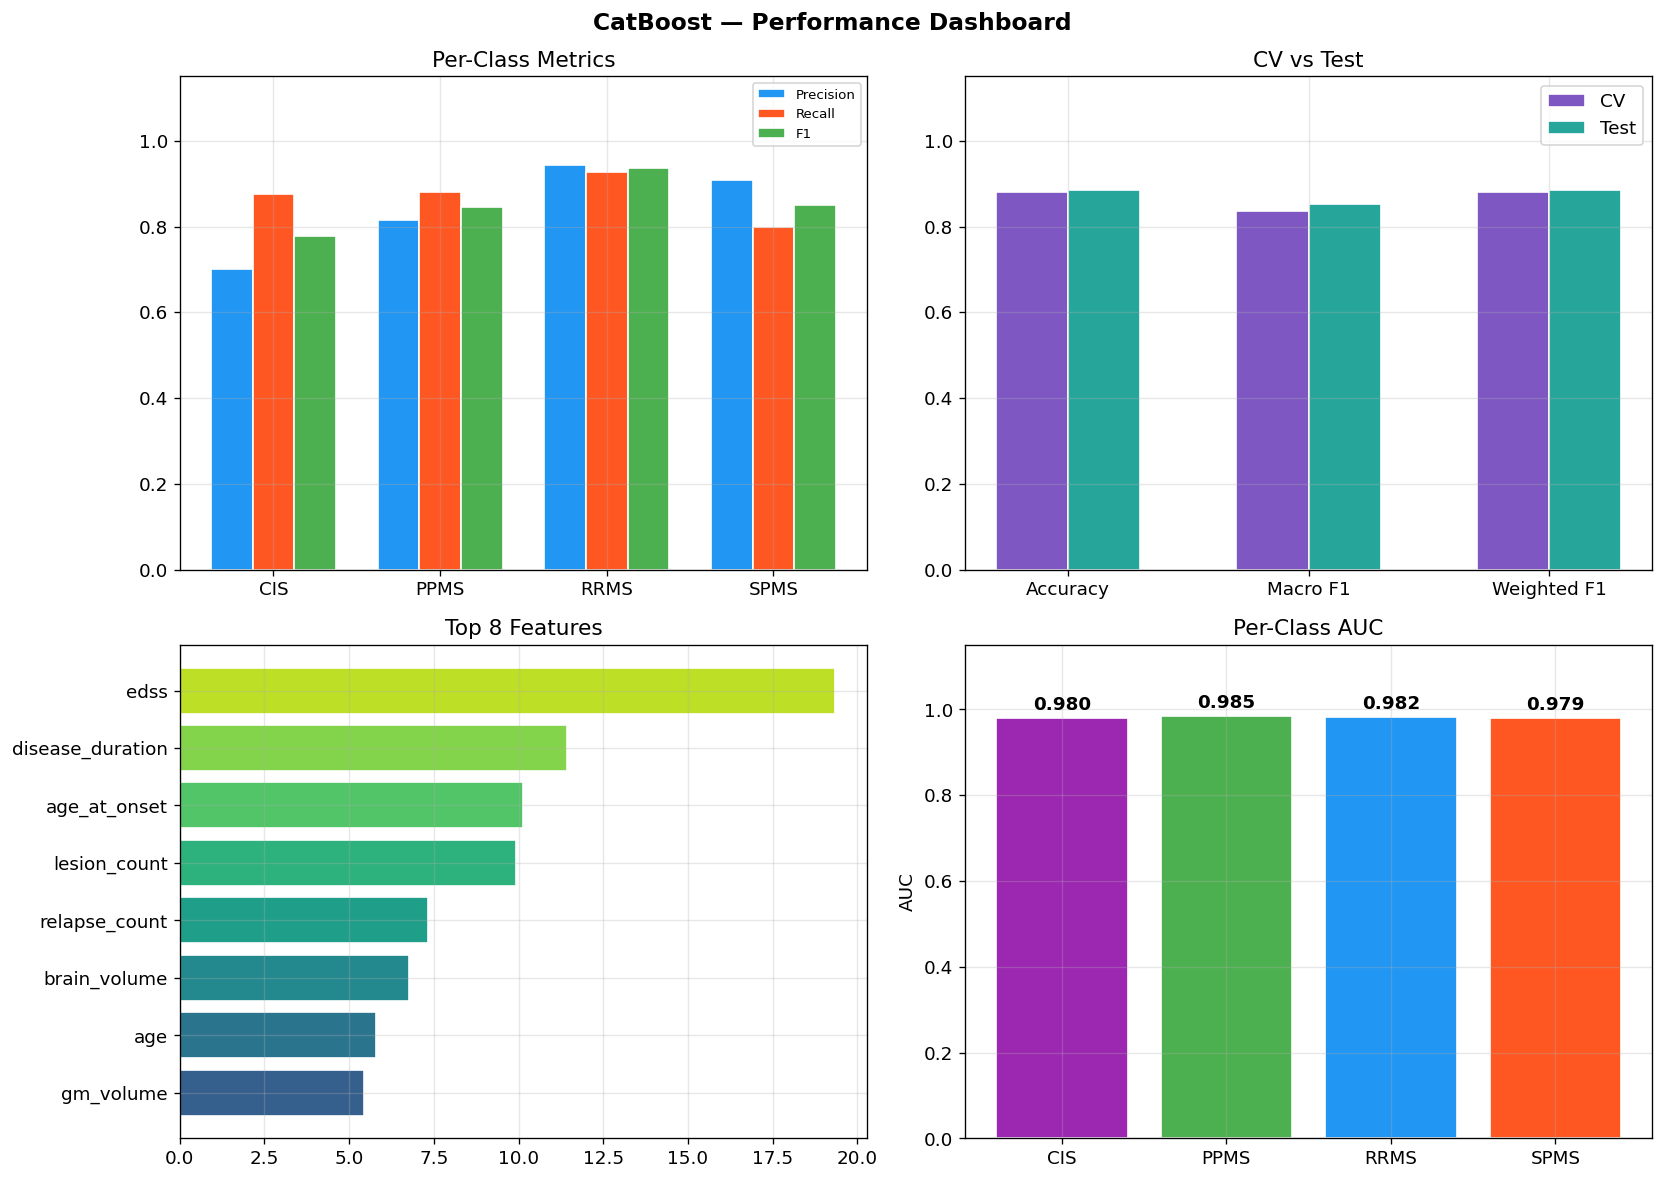

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Per-class metrics
p = precision_score(y_test, y_pred, average=None)
r = recall_score(y_test, y_pred, average=None)
f = f1_score(y_test, y_pred, average=None)
x = np.arange(len(class_names))
w = 0.25
axes[0,0].bar(x-w, p, w, label='Precision', color='#2196F3', edgecolor='white')
axes[0,0].bar(x, r, w, label='Recall', color='#FF5722', edgecolor='white')
axes[0,0].bar(x+w, f, w, label='F1', color='#4CAF50', edgecolor='white')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(class_names)
axes[0,0].set_title('Per-Class Metrics'); axes[0,0].legend(fontsize=8); axes[0,0].set_ylim(0,1.15)

# CV vs Test
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
f1w = f1_score(y_test, y_pred, average='weighted')
cv_m = [cv_results['test_accuracy'].mean(), cv_results['test_f1_macro'].mean(), cv_results['test_f1_weighted'].mean()]
t_m = [acc, f1m, f1w]
x2 = np.arange(3)
axes[0,1].bar(x2-0.15, cv_m, 0.3, label='CV', color='#7E57C2', edgecolor='white')
axes[0,1].bar(x2+0.15, t_m, 0.3, label='Test', color='#26A69A', edgecolor='white')
axes[0,1].set_xticks(x2); axes[0,1].set_xticklabels(['Accuracy','Macro F1','Weighted F1'])
axes[0,1].set_title('CV vs Test'); axes[0,1].legend(); axes[0,1].set_ylim(0,1.15)

# Feature importance
imp = model.get_feature_importance()
imp_df2 = pd.DataFrame({'Feature': feature_cols, 'Importance': imp}).sort_values('Importance').tail(8)
axes[1,0].barh(imp_df2['Feature'], imp_df2['Importance'],
               color=plt.cm.viridis(np.linspace(0.3,0.9,len(imp_df2))), edgecolor='white')
axes[1,0].set_title('Top 8 Features')

# Per-class AUC
aucs = [auc(*roc_curve(y_test_bin[:,i], y_proba[:,i])[:2]) for i in range(len(class_names))]
axes[1,1].bar(class_names, aucs, color=[COLORS[n] for n in class_names], edgecolor='white')
for i,v in enumerate(aucs): axes[1,1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1,1].set_ylabel('AUC'); axes[1,1].set_title('Per-Class AUC'); axes[1,1].set_ylim(0,1.15)

fig.suptitle('CatBoost — Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

CatBoost provides strong performance with minimal preprocessing — no scaling, no imputation, native categorical support. Its ordered boosting reduces overfitting.